In [207]:

import warnings
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [208]:
df=pd.read_csv('bangladesh_student_performance.csv')
df.shape

(2018, 16)

In [209]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,2018.000000,2018.000000,2018.000000,2018.000000,2018.00000,2018.000000,2018.000000
mean,17.981169,1.871160,2.174430,72977.637760,3.05996,3.788087,3.199177
std,0.826340,1.194206,1.252979,24045.222595,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53619.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71272.500000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,90904.750000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           2018 non-null   int64  
 3   address       2018 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         2018 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   2018 non-null   int64  
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(2), int64(5), object(9)
memory usage: 252.4+ KB


In [211]:
df.columns

Index(['date', 'gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu',
       'F_Edu', 'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

##Separating Numerical and Categorical Columns


In [212]:
numerical_data = df.select_dtypes(
    include = ['int64','float64']
).columns


In [213]:
numerical_data

Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result',
       'hsc_result'],
      dtype='object')

In [214]:
categorical_data = df.select_dtypes(
    include = ['object']
).columns

In [215]:
categorical_data

Index(['date', 'gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object')

##EDA

Showing Numerical Features

Text(0.5, 0.98, 'Distributions of Numerical Features')

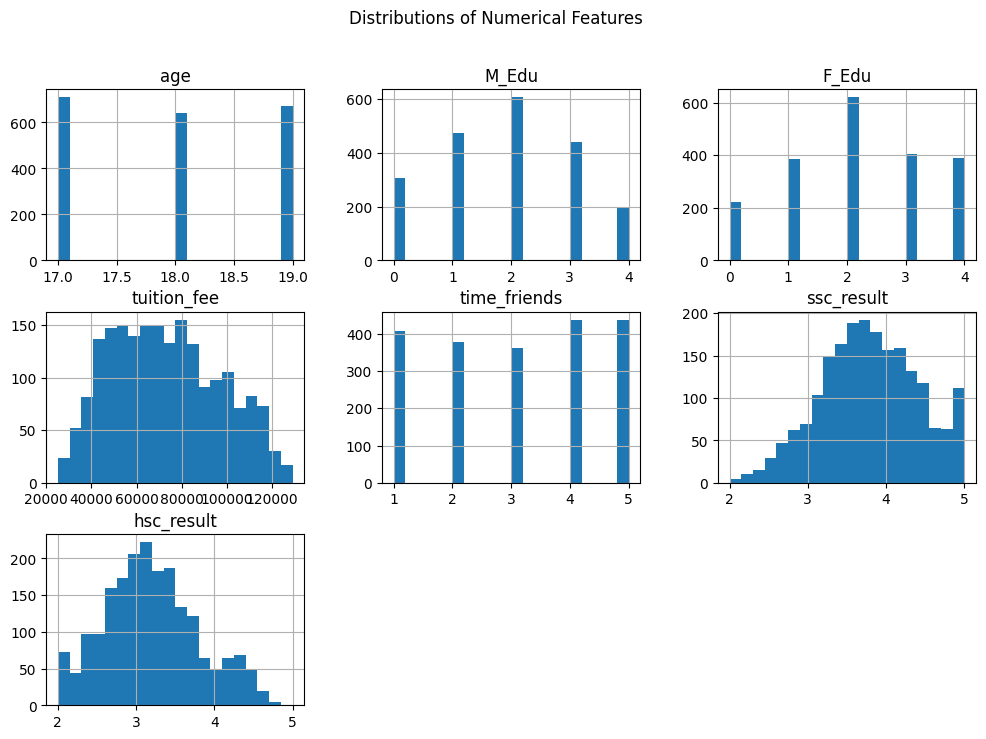

In [216]:
df.hist(figsize=(12,8),bins=20)
plt.suptitle("Distributions of Numerical Features")

Showing Categorical Features

Text(0.5, 1.0, 'Gender')

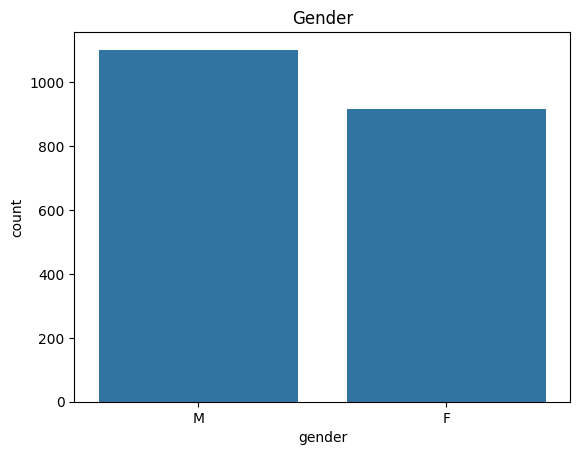

In [217]:
plt.figsize=(6,4)
sns.countplot(data=df,x='gender')
plt.title("Gender")

Text(0.5, 1.0, 'Address')

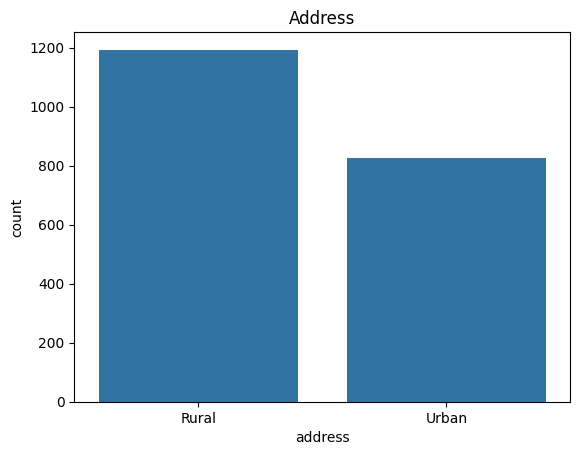

In [218]:
plt.figsize=(6,4)
sns.countplot(data=df,x='address')
plt.title("Address")

Text(0.5, 1.0, 'Family Size')

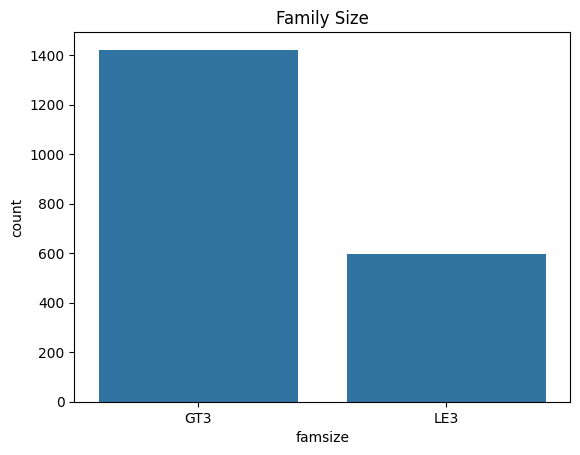

In [219]:
plt.figsize=(6,4)
sns.countplot(data=df,x='famsize')
plt.title("Family Size")

Showing Target Feature

Text(0.5, 0.98, 'Distributions of HSC Result')

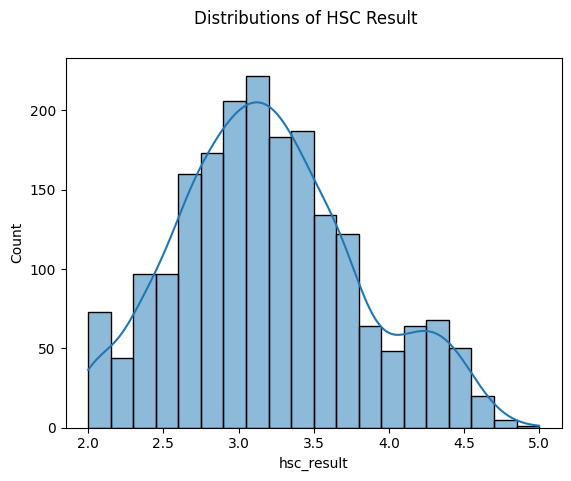

In [220]:
plt.figsize=(6,4)
sns.histplot(data=df,
             x = 'hsc_result',
             bins=20,
             kde=True)
plt.suptitle("Distributions of HSC Result")

##Co-relation Heatmap

<Axes: >

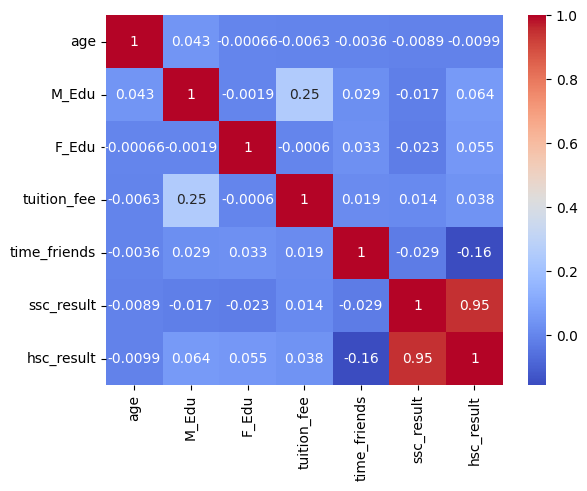

In [221]:
sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)


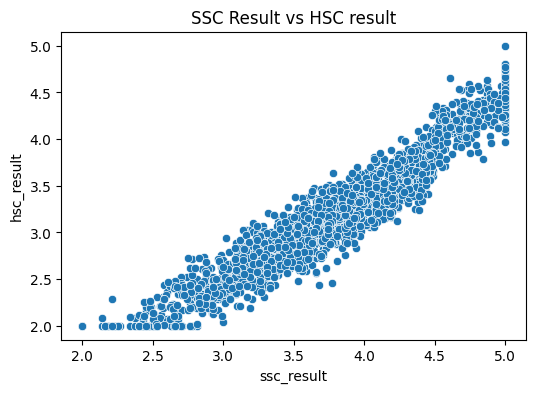

In [222]:
plt.figure(figsize = (6,4) )

sns.scatterplot(
    data = df ,
    x = "ssc_result",
    y = "hsc_result"
)

plt.title("SSC Result vs HSC result")
plt.show()


##Feature and Target

In [223]:
X=df.drop(columns=['date','hsc_result'])

In [224]:
X

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
0,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22
1,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47
2,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32
3,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57
4,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,M,18,Urban,GT3,Together,2,2,Teacher,Health,No,No,108426,2,3.57
2014,M,19,Urban,GT3,Together,0,3,Other,Teacher,Yes,No,100665,5,4.05
2015,M,18,Urban,GT3,Together,3,2,Services,Farmer,Yes,No,92291,1,3.93
2016,M,19,Rural,GT3,Together,0,2,At_home,Teacher,No,No,43926,3,3.34


In [225]:
y=df['hsc_result']

In [226]:
y

,hsc_result
0,3.72
1,2.62
2,2.56
3,4.17
4,3.94
...,...
2013,3.18
2014,3.13
2015,3.15
2016,2.83


##Numeric and Categorical Data

In [227]:
x_numerical_data =X.select_dtypes(include = ['int64','float64']).columns

In [228]:
x_numerical_data

Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')

In [229]:
x_categorical_data =X.select_dtypes(include = ['object']).columns

In [230]:
x_categorical_data

Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object')

##Pipeline:

In [231]:
numerical_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = 'median')),
        ("scaler", StandardScaler())
    ]
)





In [232]:
numerical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [233]:
categorical_transformer = Pipeline(
    steps = [
        ("imputer",SimpleImputer(strategy= 'most_frequent')),
        ("encoding",OneHotEncoder(handle_unknown = 'ignore'))
    ]
)

In [234]:
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoding', OneHotEncoder(handle_unknown='ignore'))])

Preprocessor:

In [235]:
preprocessor = ColumnTransformer(
    transformers = [
        ("Numerical",numerical_transformer,x_numerical_data),
        ("Categorical",categorical_transformer,x_categorical_data)
    ]
)

In [236]:
preprocessor

ColumnTransformer(transformers=[('Numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')),
                                ('Categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoding',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object'))])

##Spliting Data

In [237]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size =0.2,random_state=42)

In [238]:
X_train

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
746,M,19,Rural,LE3,Together,2,2,Other,Services,No,No,49318,3,4.95
1381,M,17,Urban,GT3,Together,0,1,Health,Farmer,No,Yes,88032,5,2.68
240,F,17,Urban,GT3,Together,4,3,Other,Services,No,No,116230,4,3.75
1646,M,18,Urban,LE3,Apart,2,1,Other,Business,No,No,79334,3,3.70
1460,M,18,Rural,GT3,Apart,4,3,At_home,Farmer,No,No,80248,2,3.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,F,18,Rural,GT3,Together,2,2,At_home,Health,No,No,50003,1,3.83
1294,F,19,Urban,LE3,Together,2,3,At_home,Farmer,Yes,No,110895,2,3.30
860,F,19,Rural,GT3,Together,0,2,Health,Farmer,No,No,51576,1,5.00
1459,F,18,Rural,GT3,Together,2,4,Other,Services,No,No,45830,1,4.42


In [239]:
X_test

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,17,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743,1,3.88
526,M,19,Rural,GT3,Together,4,3,At_home,Business,No,No,58678,5,4.36
393,F,18,Urban,GT3,Together,2,1,Services,Services,No,No,115832,3,4.47
1789,M,17,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781,1,4.43
433,M,19,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345,4,3.47
693,M,19,Urban,GT3,Together,1,2,Health,Business,No,No,85346,4,2.96
1494,F,18,Rural,LE3,Together,1,4,Teacher,Teacher,No,No,30638,1,3.76
921,M,19,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804,2,4.18


##linear Regression using Pipeline

In [240]:
lr_pipeline = Pipeline(
    steps = [
        ('Preprocessor', preprocessor),
        ('', LinearRegression())
    ]
    )
lr_pipeline.fit(X_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('Numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')),
                                                 ('Categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object'))])),
                ('', LinearRegression())])

In [241]:
lr_pipeline.predict(X_test)

array([3.22669684, 3.75113021, 3.83030552, 4.00812429, 3.90813125,
       3.33268499, 3.98238917, 2.54100569, 1.97989523, 3.27136765,
       3.67618639, 2.91974684, 3.23916997, 4.27745666, 3.03796909,
       2.67666797, 3.71635128, 3.45139645, 2.80448432, 2.96032266,
       2.82279738, 3.20360175, 2.99955789, 3.21756623, 1.89824069,
       2.58427455, 3.18535317, 3.82782921, 3.08736856, 3.94791665,
       2.41118168, 3.94402908, 4.31536621, 2.56485679, 3.1906842 ,
       3.26168549, 2.76183262, 3.65744712, 2.48538661, 2.6087985 ,
       3.07530752, 2.97249903, 3.73751782, 2.76766138, 2.17550874,
       3.06821563, 2.62014172, 2.6103055 , 4.03595945, 3.26038622,
       3.07496713, 3.45228036, 4.23442796, 3.63506638, 3.07127632,
       3.19967274, 3.29198851, 2.67393509, 3.81513176, 2.68699449,
       3.00552459, 2.76655742, 2.49090392, 4.43182742, 2.56047125,
       3.21025981, 3.96789734, 2.66949768, 3.03343159, 3.21841769,
       3.03009111, 2.722802  , 2.61470787, 3.63521455, 3.08131

####SGD using Pipeline

In [242]:
Alpha= 0.001
Max_iter=10000
ETA = 0.01
sgd_pipeline = Pipeline(
    steps = [
        ('Preprocessor', preprocessor),
        ('model', SGDRegressor(
        loss = 'squared_error',
        alpha=Alpha,
        penalty = 'l2',
        max_iter = Max_iter,
        eta0=ETA,
        learning_rate = 'constant',
        random_state=42)
)
        ]
    )
sgd_pipeline.fit(X_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('Numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')),
                                                 ('Categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object'))])),
                ('model',
                 SGDRegressor(alpha=0.001, learning_rate='constant',
                              max_iter=10000, random_state=42))])

In [243]:
sgd_pipeline.predict(X_train)

array([4.35389213, 1.99638451, 3.33777321, ..., 4.44437868, 4.04546477,
       2.97503475])

##Evaluation function:

In [263]:
def evaluate(model, name):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print(f"\n{name}")
    print("-"*40)

    print("Train R2 :", round(r2_score(y_train, train_pred),4))
    print("Test R2  :", round(r2_score(y_test, test_pred),4))
    print("RMSE     :", round(np.sqrt(mean_squared_error(y_test, test_pred)),4))
    print("MAE      :", round(mean_absolute_error(y_test, test_pred),4))

    return (
        r2_score(y_test, test_pred),
        np.sqrt(mean_squared_error(y_test, test_pred)),
        mean_absolute_error(y_test, test_pred)
    ) #if we don't want to see any value we can write only 'return()'


In [262]:
lr_r2 ,lr_rmse,lr_mase = evaluate(
    lr_pipeline,
    "Linear Regression"
)
print(lr_r2 ,lr_rmse,lr_mase)


Linear Regression
----------------------------------------
Train R2 : 0.9466
Test R2  : 0.9459
RMSE     : 0.1424
MAE      : 0.1114
0.9459200678311974 0.14237094951498758 0.1113761481152391


##Cross Validation:

In [265]:

cv_scores = cross_val_score(
    lr_pipeline,
    X ,
    y,
    cv = 5 ,
    scoring = "r2"
)

print("Scores ", cv_scores)
print("Average Cv 42", cv_scores.mean())

Scores  [0.94815437 0.95301409 0.93902546 0.94315463 0.94180106]
Average Cv 42 0.9450299231558873


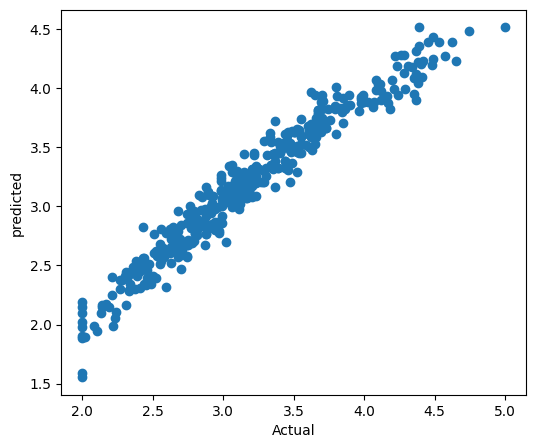

In [264]:
# actual vs predicted

y_pred = lr_pipeline.predict(X_test)

plt.figure(figsize = (6,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual")
plt.ylabel("predicted")

plt.show()